<a href="https://colab.research.google.com/github/Rezi277/Latihan06-ML/blob/main/Latihan06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# membaca file csv menggunakan pandas
df = pd.read_csv('/content/drive/MyDrive/Latihan-2.ML/Praktikum06.ML/Data/wine_food_pairings.csv')

# cetak header data (5 baris data) dari file
df.head()

,wine_type,wine_category,food_item,food_category,cuisine,pairing_quality,quality_label,description
0,Syrah/Shiraz,Red,smoked sausage,Smoky BBQ,Spanish,2,Poor,Heuristic pairing assessment.
1,Grenache,Red,charcuterie board,Salty Snack,French,3,Neutral,Heuristic pairing assessment.
2,Madeira,Fortified,lemon tart,Dessert,French,4,Good,Acidic wine balances acidic food.
3,Cabernet Sauvignon,Red,roast lamb,Red Meat,Mexican,5,Excellent,Tannic red complements red meat fat.
4,Viognier,White,duck à l’orange,Poultry,Vietnamese,2,Poor,Heuristic pairing assessment.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34933 entries, 0 to 34932
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   wine_type        34933 non-null  object
 1   wine_category    34933 non-null  object
 2   food_item        34933 non-null  object
 3   food_category    34933 non-null  object
 4   cuisine          34933 non-null  object
 5   pairing_quality  34933 non-null  int64 
 6   quality_label    34933 non-null  object
 7   description      34933 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.1+ MB


In [ ]:
df.describe()

,pairing_quality
count,34933.000000
mean,3.015115
std,1.409591
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [ ]:
df["quality_label"].unique()

array(['Poor', 'Neutral', 'Good', 'Excellent', 'Terrible'], dtype=object)

In [ ]:
df["quality_label"].value_counts()

,count
quality_label,
Neutral,8108
Excellent,7163
Terrible,7034
Good,6449
Poor,6179


In [ ]:
X = df[['wine_type', 'wine_category', 'food_item', 'food_category', 'cuisine' ]]

# Kolom target (label)
y = df['quality_label']

In [ ]:
X.head()

,wine_type,wine_category,food_item,food_category,cuisine
0,Syrah/Shiraz,Red,smoked sausage,Smoky BBQ,Spanish
1,Grenache,Red,charcuterie board,Salty Snack,French
2,Madeira,Fortified,lemon tart,Dessert,French
3,Cabernet Sauvignon,Red,roast lamb,Red Meat,Mexican
4,Viognier,White,duck à l’orange,Poultry,Vietnamese


In [ ]:
y.head()

,quality_label
0,Poor
1,Neutral
2,Good
3,Excellent
4,Poor


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_features = ['wine_type', 'wine_category', 'food_item', 'food_category', 'cuisine']

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)],
    remainder='passthrough')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

model = SVC(kernel='linear')
model.fit(X_train_processed, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = model.predict(X_test_processed)
# Akurasi
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")
# Laporan klarifikasi
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 20.50%

Laporan Klasifikasi:
               precision    recall  f1-score   support

   Excellent       0.17      0.16      0.17      1403
        Good       0.21      0.15      0.17      1326
     Neutral       0.22      0.51      0.31      1597
        Poor       0.16      0.06      0.09      1240
    Terrible       0.20      0.08      0.11      1421

    accuracy                           0.20      6987
   macro avg       0.19      0.19      0.17      6987
weighted avg       0.19      0.20      0.18      6987



In [ ]:
# mapping label -> kode untuk target
quality_label_cat = df['quality_label'].astype('category')
quality_label_classes = list(quality_label_cat.cat.categories)
df['quality_label'] = quality_label_cat.cat.codes

# fitur kategorikal lain (jenis_kelamin, wasting)
for col in ['wine_type', 'wine_category']:
  if col in df.columns:
    df[col] = df[col].astype('category').cat.codes

df.head()

,wine_type,wine_category,food_item,food_category,cuisine,pairing_quality,quality_label,description
0,23,2,smoked sausage,Smoky BBQ,Spanish,2,3,Heuristic pairing assessment.
1,9,2,charcuterie board,Salty Snack,French,3,2,Heuristic pairing assessment.
2,12,1,lemon tart,Dessert,French,4,1,Acidic wine balances acidic food.
3,2,2,roast lamb,Red Meat,Mexican,5,0,Tannic red complements red meat fat.
4,26,5,duck à l’orange,Poultry,Vietnamese,2,3,Heuristic pairing assessment.


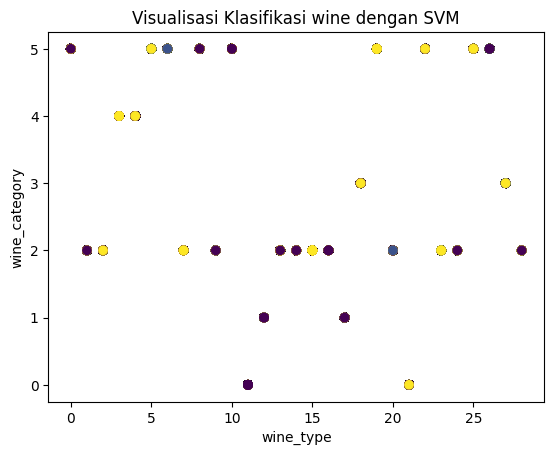

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['wine_type'], df['wine_category'], c=df['quality_label'].astype('category').cat.codes)
plt.xlabel('wine_type')
plt.ylabel('wine_category')
plt.title('Visualisasi Klasifikasi wine dengan SVM')
plt.show()


Confusion Matrix:
 [[230 165 783  78 147]
 [228 201 708 102  87]
 [316 209 815 117 140]
 [239 242 605  76  78]
 [325 160 721 105 110]]


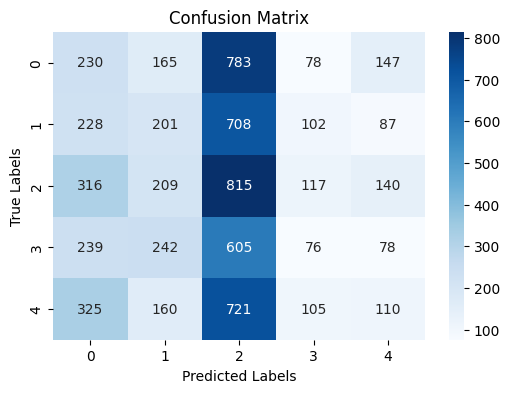

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

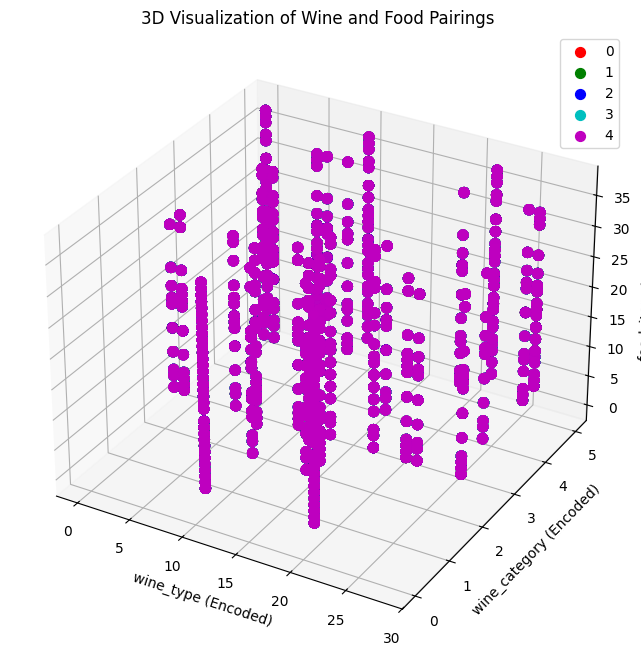

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import pandas as pd

df_plot = df.copy()

le_wine_type = LabelEncoder()
df_plot['wine_type_encoded'] = le_wine_type.fit_transform(df_plot['wine_type'])

le_wine_category = LabelEncoder()
df_plot['wine_category_encoded'] = le_wine_category.fit_transform(df_plot['wine_category'])

le_food_item = LabelEncoder()
df_plot['food_item_encoded'] = le_food_item.fit_transform(df_plot['food_item'])

le_quality = LabelEncoder()
df_plot['quality_label_encoded'] = le_quality.fit_transform(df_plot['quality_label'])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm']
labels = le_quality.classes_

for i, label in enumerate(labels):
    subset = df_plot[df_plot['quality_label_encoded'] == i]
    ax.scatter(
        subset['wine_type_encoded'],
        subset['wine_category_encoded'],
        subset['food_item_encoded'],
        color=colors[i % len(colors)],
        label=label,
        s=50
    )

ax.set_xlabel('wine_type (Encoded)')
ax.set_ylabel('wine_category (Encoded)')
ax.set_zlabel('food_item (Encoded)')
ax.set_title('3D Visualization of Wine and Food Pairings')
ax.legend()
plt.show()